In [10]:
# %load_ext autoreload
# %autoreload 2
import os, sys

import PATH
import scanpy as sc
import anndata as ad
import numpy as np
from src import _sampler
from src import _learner
from src import _reader

import torch
from torch import nn
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader

In [2]:
import scvelo

In [3]:
from src._configure import Yaml_configurer

sys.path.append(os.path.join(PATH.main_dir, "script"))

from script.main_train_with_PL_trainer import dl_from_config, get_model_from_config, get_sampler_from_configs
import PATH
from src import _diffplot as dfp
import pandas as pd

/home/wergillius/Project/diffuse_differentiate/script/path_n_util.py
/home/wergillius/Project/diffuse_differentiate/machine_config.json


In [4]:
# config
model_config = os.path.join(PATH.main_dir, "configs/TF_atlas/TF_diff/H256_d3.yaml")
configs = Yaml_configurer(model_config)

# model checkpoint
relative_path = 'TF_diff/Epsilon_Linear_H256_d3/lightning_logs/version_0'
ckpt_path = dfp.get_ckpt_path(relative_path)

In [5]:
from importlib import reload
reload(dfp)

<module 'src._diffplot' from '/home/wergillius/Project/diffuse_differentiate/src/_diffplot.py'>

In [6]:
adata_zc, model  = dfp.plot_representation(
    yaml_path = model_config,
    ckpt_path = relative_path,
    use_rep = 'z_c',
    n_neighbors= 60,
    device = 0
)

loadin adata with 28825 cells, which normally takes around 5.54 mins


100%|██████████| 91/91 [00:01<00:00, 82.08it/s] 



cell embedding extracted, ready to computing KNN...

KNN constructed, computing UMAP...


In [7]:
from script.main_train_with_PL_trainer import dl_from_config

In [8]:
adata_zc

AnnData object with n_obs × n_vars = 28825 × 4806
    obs: 'TF', 'batch', 'louvain', 'n_counts', 'n_genes', 'percent_mito', 'dpt_pseudotime', 'discrete_time', 'split'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'batch_colors', 'diffmap_evals', 'hvg', 'iroot', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'umap', 'unique_token_dict', 'z_c'
    obsm: 'X_diffmap', 'X_pca', 'X_pca_harmony', 'X_umap', 'delta_x', 'z_c', 'z', 'c'
    varm: 'PCs'
    obsp: 'connectivities', 'distances', 'z_c_distances', 'z_c_connectivities'

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


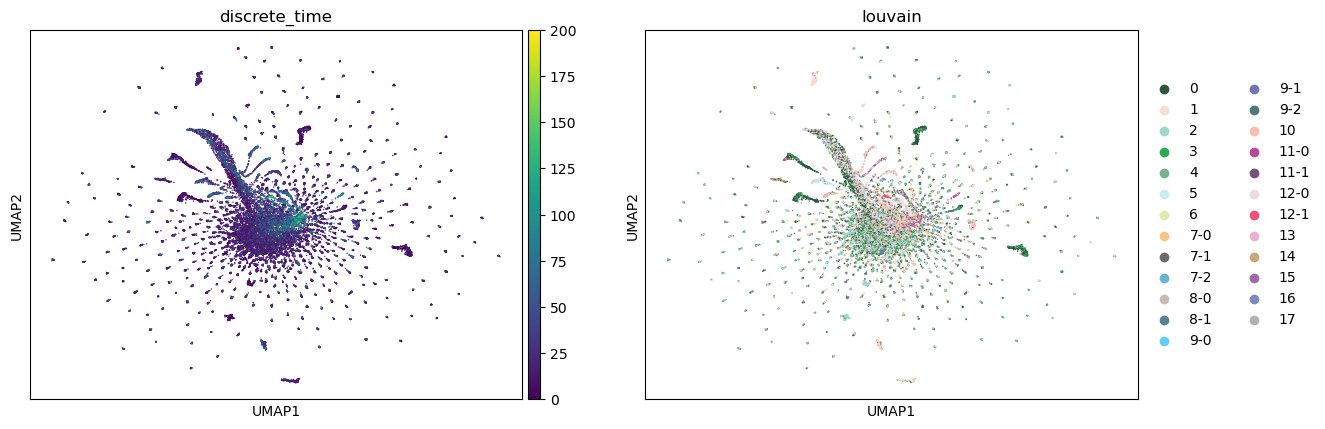

In [11]:
sc.pl.umap(adata_zc, color=['discrete_time','louvain'])

# condition embedding

In [22]:
path = f"{main_dir}/TF_subs/Epsilon_Linear_large_batch/lightning_logs/version_0/checkpoints/epoch=0-step=4250.ckpt"

In [24]:
os.path.exists(path)

True

In [ ]:
TFsub_model = f"{main_dir}/configs/TF_atlas/TF_subs/large_batch.yaml"

In [ ]:
TFsub_model = TFsub_model.eval().to('cpu')

In [ ]:
embedder = sub_model.model.embedder.weight.detach().numpy()

In [ ]:
embedder.shape

In [ ]:
TF_summary = adata.obs.groupby("TF").agg({'dpt_pseudotime':"max",
                            "split" : 'count'
                             })

In [ ]:
large_dpt_TF = TF_summary.dpt_pseudotime.nlargest(200).index

In [ ]:
token_lokup = adata.uns['unique_token_dict']
unique_TF = adata.obs.TF.unique()
existed_TF = [token_lokup[tf] for tf in adata.obs.TF.unique()]

In [ ]:
large_dpt_token = [token_lokup[tf] for tf in large_dpt_TF]

In [ ]:
large_dpt_emb = embedder[large_dpt_token,:]

In [ ]:
existed_emb = embedder[existed_TF,:]

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import KernelPCA
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
from umap import UMAP

In [ ]:
emb_pca=KernelPCA(kernel='cosine').fit(existed_emb)
emb_pca_ay=emb_pca.transform(existed_emb)

In [ ]:
existed_umap = UMAP(n_neighbors = 15, metric = "euclidean", output_metric = 'euclidean').fit_transform(existed_emb)

In [ ]:
cosine_umap = UMAP(n_neighbors = 15, metric = "cosine", output_metric = 'euclidean').fit_transform(existed_emb)

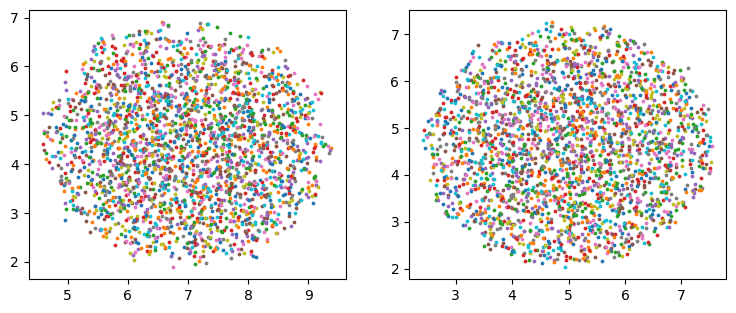

In [138]:
fig, ax = plt.subplots(1,2, figsize=(9,3.5), dpi=100)
for i, t in enumerate(unique_TF):
    ax[0].scatter( existed_umap[i,0],  existed_umap[i,1], s=3, label=t)

    ax[1].scatter( cosine_umap[i,0],  cosine_umap[i,1], s=3,
                label=t)

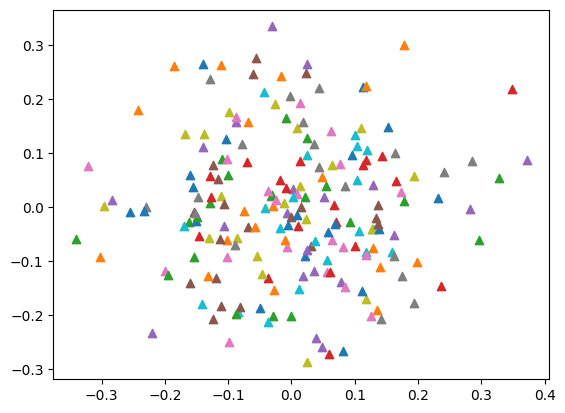

In [120]:
fig, ax = plt.subplots(1,1)
for i, t in enumerate(large_dpt_TF):
    ax.scatter( emb_pca_ay[i,0],  emb_pca_ay[i,1], 
            marker='^',label=t)
    
# plt.legend(ncol=3, fontsize=8)

In [117]:
cosine_m = cosine_similarity(existed_emb)
for i in range(cosine_m.shape[0]):
    cosine_m[i,i] = 0

In [118]:
cosine_sim_df = pd.DataFrame(cosine_m, columns=large_dpt_TF, index=large_dpt_TF)

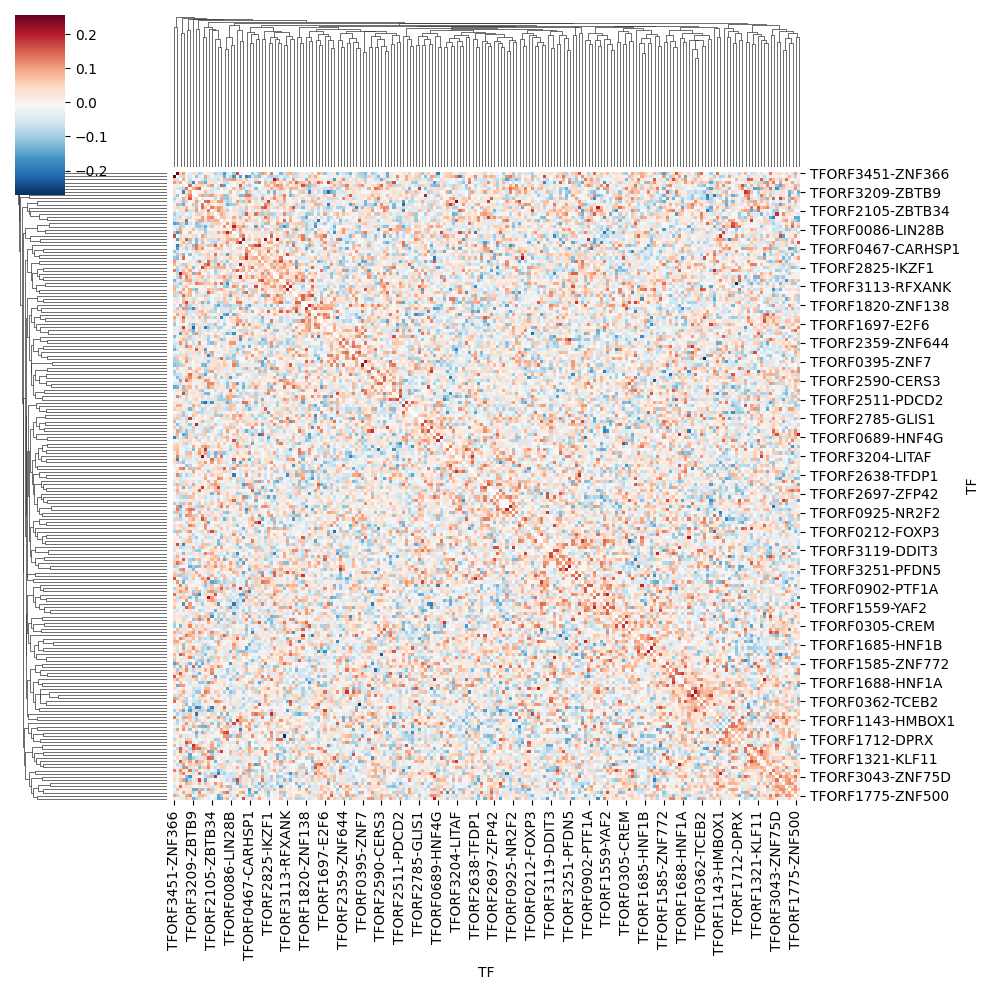

In [119]:
sns.clustermap(data=cosine_sim_df, mask=np.diag(np.ones((cosine_m.shape[0]),)),cmap='RdBu_r')

# Velocity

In [15]:
adata = sc.read_h5ad(os.path.join(PATH.main_dir, "data/TFAtlas/GSE217460_210322_TFAtlas_differentiated.h5ad"))

In [16]:
origin_idx = adata.obs.index
velocity_matrix = adata_zc[origin_idx].obsm['delta_x']

In [17]:
adata_zc1 = dfp.compute_velocity(
    adata=adata,
    velocity_matrix = velocity_matrix,
    n_jobs = 40
)

computing velocity graph (using 40/48 cores)
or disable the progress bar using `show_progress_bar=False`.


/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scvelo/core/_parallelize.py:138: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  res = np.array(res) if as_array else res


    finished (0:04:27) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [19]:
adata_zc1

AnnData object with n_obs × n_vars = 28825 × 4806
    obs: 'TF', 'batch', 'louvain', 'n_counts', 'n_genes', 'percent_mito', 'dpt_pseudotime', 'discrete_time', 'split', 'velocity_self_transition'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'batch_colors', 'diffmap_evals', 'hvg', 'iroot', 'louvain', 'louvain_colors', 'pca', 'umap', 'unique_token_dict', 'neighbors', 'velocity_graph', 'velocity_graph_neg', 'velocity_params'
    obsm: 'X_diffmap', 'X_pca', 'X_pca_harmony', 'X_umap', 'velocity_umap'
    varm: 'PCs'
    layers: 'velocity', 'X'
    obsp: 'connectivities', 'distances'

AttributeError: can't set attribute

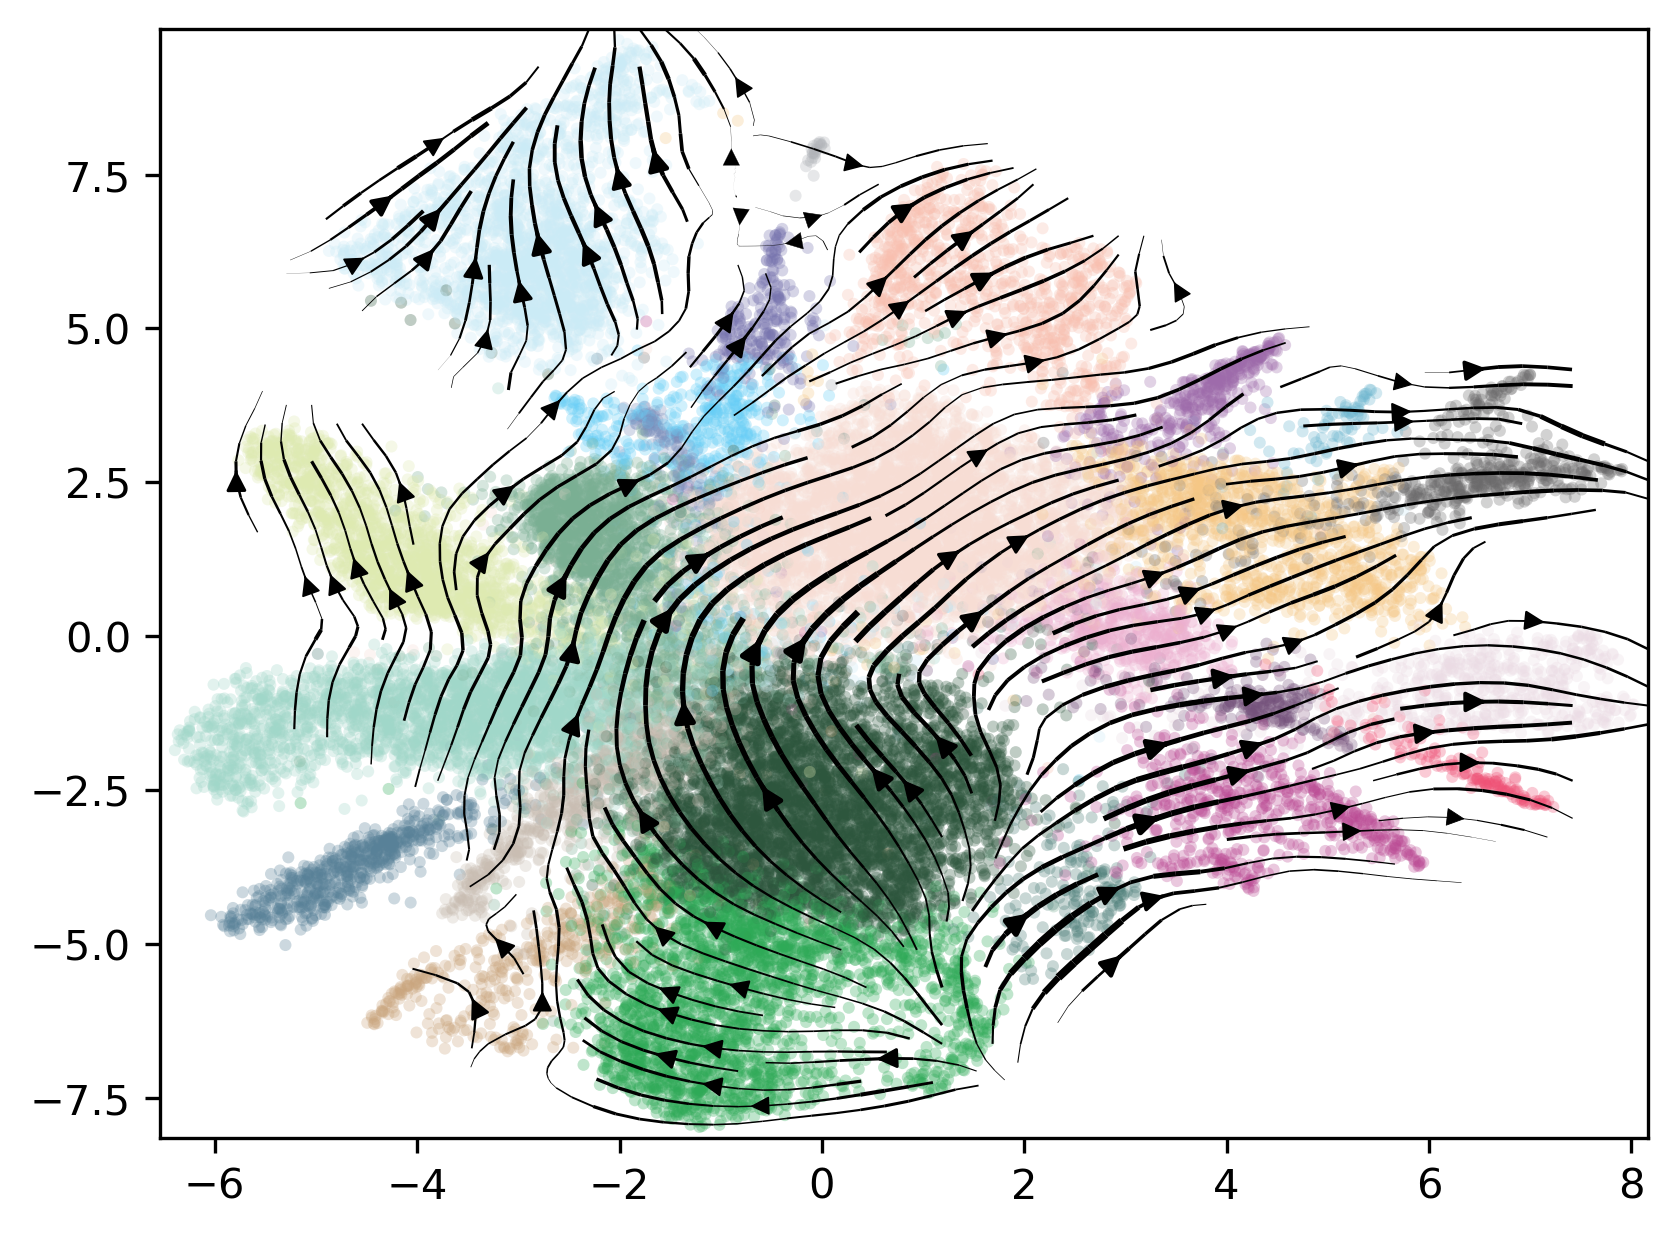

In [20]:
scvelo.pl.velocity_embedding_stream(adata_zc1,
                                    color='louvain', 
                                    legend_loc='far right', dpi=300)

In [26]:
adata_zc1.obs.index == adata_zc.obs.index

array([ True,  True,  True, ...,  True,  True,  True])

In [ ]:
'delta_x', 'z_c', 'z', 'c'

In [ ]:
adata_zc1.obsm['z_c'] 

In [21]:
adata_zc1.write_h5ad(os.path.join(PATH.main_dir, "data/TFAtlas/differentiated_model_velo.h5ad"))